# Phase 1 -- EBM Interpretability Kit


This notebook trains lightweight EBMs on three representative targets (d1, d7, d14) and
visualizes the learned structure. Focus is on interpretability, not on competitive scoring.

## 1. Setup

In [ ]:
import os, sys
# Ensure we're in the notebook's directory (participant_kit/phase1/)
_this_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else None
if _this_dir is None:
    for _candidate in [os.getcwd(), os.path.join(os.getcwd(), "participant_kit", "phase1")]:
        if os.path.exists(os.path.join(_candidate, "utils.py")):
            os.chdir(_candidate)
            break
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from time import time

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)

# Check interpret is installed
try:
    from interpret.glassbox import ExplainableBoostingRegressor
    print("InterpretML version:", __import__("interpret").__version__)
except ImportError:
    raise ImportError(
        "InterpretML not found. Install with:\n"
        "  pip install interpret\n"
        "Then restart the kernel."
    )

from utils import (
    load_train_data, exclude_worldwide_features,
    load_or_compute_selection, winkler_score,
    HORIZONS, HOURS,
)

FEATURES_DIR = Path("phase1_dataset/features")
print("Ready.")


## 2. Load Data

We use **north_sea** only -- it is the more interesting region (stronger HRES signal, clearer
seasonal cycle) and keeps training fast. We exclude worldwide features (NAO proxy, Siberian
High, upstream stations, etc.) since they add noise for local speed prediction.

In [2]:
REGION = "north_sea"

df, feature_cols, speed_targets, dir_targets = load_train_data(FEATURES_DIR, REGION)
feature_cols = exclude_worldwide_features(feature_cols)

print(f"Rows: {len(df):,}  |  Features: {len(feature_cols)}  |  Speed targets: {len(speed_targets)}")
print(f"Years: {sorted(df['time'].dt.year.unique())}")
print(f"\nFeature sample: {feature_cols[:10]}")
print(f"Speed targets:  {speed_targets}")

Rows: 2,811,240  |  Features: 74  |  Speed targets: 12
Years: [np.int32(2019), np.int32(2020), np.int32(2021)]

Feature sample: ['blh', 'cape', 'elevation', 'fcst_dir_d10_h0', 'fcst_dir_d10_h12', 'fcst_dir_d10_h18', 'fcst_dir_d10_h6', 'fcst_dir_d1_h0', 'fcst_dir_d1_h12', 'fcst_dir_d1_h18']
Speed targets:  ['speed_d14_h0', 'speed_d14_h12', 'speed_d14_h18', 'speed_d14_h6', 'speed_d1_h0', 'speed_d1_h12', 'speed_d1_h18', 'speed_d1_h6', 'speed_d7_h0', 'speed_d7_h12', 'speed_d7_h18', 'speed_d7_h6']


## 3. Train / Validation Split

- **Train**: 2019-2020 (2 years)
- **Validation**: 2021 (1 year)

**100K rows** subsampling for training.

In [3]:
SUBSAMPLE = 100_000
RANDOM_STATE = 42

train_mask = df["time"].dt.year.isin([2019, 2020])
val_mask = df["time"].dt.year == 2021

df_train_full = df[train_mask]
df_val_full = df[val_mask]

# Subsample training data
if len(df_train_full) > SUBSAMPLE:
    df_train_full = df_train_full.sample(n=SUBSAMPLE, random_state=RANDOM_STATE)

print(f"Train: {len(df_train_full):,} rows  |  Val: {len(df_val_full):,} rows")

Train: 100,000 rows  |  Val: 936,225 rows


## 4. Feature Selection (top-25 per target)

EBMs become slow with many features because they test all pairs for interactions.
We use quick LGBM importance to select the **top 25 features per target**, then train
EBMs on that reduced set.

In [4]:
EBM_TARGETS = ["speed_d1_h0", "speed_d7_h0", "speed_d14_h0"]
TOP_K_EBM = {1: 25, 7: 25, 14: 25}

# Compute or load cached feature selection (LGBM-based)
cache_path = FEATURES_DIR / "feature_selection_ebm_north_sea.json"
selected_features = load_or_compute_selection(
    cache_path, df, feature_cols, EBM_TARGETS,
    model_type="lgbm", top_k=TOP_K_EBM,
)

for tgt in EBM_TARGETS:
    print(f"\n{tgt} ({len(selected_features[tgt])} features):")
    print(f"  {selected_features[tgt]}")

Loaded cached feature selection: feature_selection_ebm_north_sea.json (3 targets)

speed_d1_h0 (25 features):
  ['fcst_speed_d1_h0', 'elevation', 'ws10_h18', 'longitude', 'wd10_h18', 'fcst_dir_d1_h0', 'fcst_speed_d1_h6', 'latitude', 'fcst_dir_d1_h6', 'sst', 'msl_h18', 'ws10_rmean7d', 'msl_h6', 'msl', 'woy_cos', 'ws10_daily_range', 'fcst_dir_d1_h12', 'wd10_h6', 'ws10_daily_mean', 'msl_lag7d', 'ws10_h6', 'woy_sin', 'fcst_dir_d7_h6', 'msl_lag1d', 'fcst_speed_d1_h12']

speed_d7_h0 (25 features):
  ['woy_cos', 'woy_sin', 'msl_lag7d', 'msl_lag1d', 'msl_lag3d', 'fcst_speed_d7_h0', 'z700_lag3d', 'msl_h18', 'fcst_speed_d7_h6', 'ws10_rmean7d', 'latitude', 'fcst_dir_d7_h0', 'fcst_speed_d7_h12', 'fcst_dir_d7_h6', 'fcst_speed_d7_h18', 'msl_h6', 'z700_lag1d', 'msl', 'z700_lag7d', 'ws10_rmean3d', 'wd10_lag1d', 't2m_lag1d', 'fcst_dir_d7_h18', 'ws10_lag3d', 'blh']

speed_d14_h0 (25 features):
  ['woy_cos', 'woy_sin', 'msl_lag7d', 'msl_lag3d', 'msl_h18', 'msl_lag1d', 'latitude', 'z700_lag3d', 'z700_lag7

## 5. Train EBMs

In [5]:
ebm_models = {}
ebm_scores = {}

for tgt in EBM_TARGETS:
    print(f"\n{'='*60}")
    print(f"Training EBM for {tgt}")
    print(f"{'='*60}")

    feats = selected_features[tgt]

    # Prepare data
    y_train = df_train_full[tgt].dropna()
    X_train = df_train_full.loc[y_train.index, feats].fillna(0)

    y_val = df_val_full[tgt].dropna()
    X_val = df_val_full.loc[y_val.index, feats].fillna(0)

    print(f"  Train: {len(X_train):,} x {len(feats)} features")
    print(f"  Val:   {len(X_val):,} x {len(feats)} features")

    ebm = ExplainableBoostingRegressor(
        max_bins=256,
        interactions=10,
        outer_bags=4,
        inner_bags=0,
        max_rounds=5000,
        early_stopping_rounds=50,
    )

    t0 = time()
    ebm.fit(X_train, y_train)
    elapsed = time() - t0
    print(f"  Trained in {elapsed:.1f}s")

    # Evaluate
    pred_train = ebm.predict(X_train)
    pred_val = ebm.predict(X_val)
    rmse_train = np.sqrt(np.mean((pred_train - y_train.values) ** 2))
    rmse_val = np.sqrt(np.mean((pred_val - y_val.values) ** 2))

    print(f"  Train RMSE: {rmse_train:.3f} m/s")
    print(f"  Val   RMSE: {rmse_val:.3f} m/s")

    ebm_models[tgt] = ebm
    ebm_scores[tgt] = {"rmse_train": rmse_train, "rmse_val": rmse_val, "time_s": elapsed}

print("\n\nSummary:")
summary = pd.DataFrame(ebm_scores).T
summary.index.name = "target"
print(summary.to_string(float_format="{:.3f}".format))


Training EBM for speed_d1_h0
  Train: 100,000 x 25 features
  Val:   936,225 x 25 features


  Trained in 19.9s
  Train RMSE: 0.930 m/s
  Val   RMSE: 0.959 m/s

Training EBM for speed_d7_h0


  Train: 100,000 x 25 features
  Val:   936,225 x 25 features


  Trained in 32.5s
  Train RMSE: 2.334 m/s
  Val   RMSE: 3.065 m/s

Training EBM for speed_d14_h0


  Train: 100,000 x 25 features
  Val:   936,225 x 25 features


  Trained in 33.5s
  Train RMSE: 2.377 m/s
  Val   RMSE: 3.409 m/s


Summary:
              rmse_train  rmse_val  time_s
target                                    
speed_d1_h0        0.930     0.959  19.888
speed_d7_h0        2.334     3.065  32.455
speed_d14_h0       2.377     3.409  33.472


## 6. Global Feature Importance

We plot the top-20 features for each horizon to see how importance shifts from NWP-dominated
(short-term) to climatology-dominated (long-term).

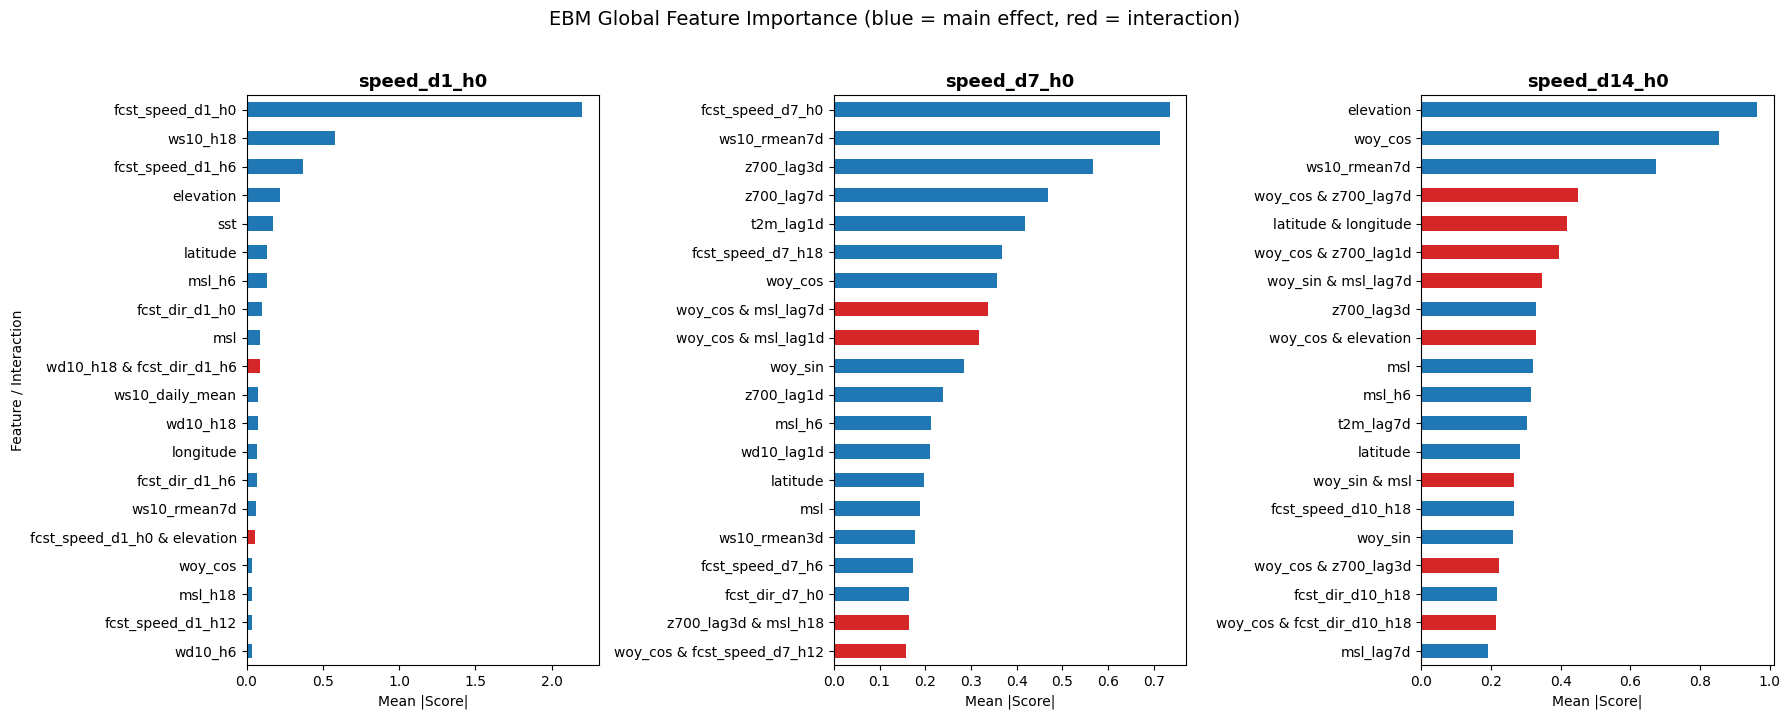

In [6]:
try:
    fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)
    
    importance_dfs = {}
    
    for ax, tgt in zip(axes, EBM_TARGETS):
        ebm = ebm_models[tgt]
        ebm_global = ebm.explain_global()
    
        names = ebm_global.data()["names"]
        scores = ebm_global.data()["scores"]
        imp = pd.Series(scores, index=names).sort_values(ascending=False)
    
        # Separate main effects from interactions for coloring
        is_interaction = imp.index.str.contains(" & ")
        colors = ["#d62728" if x else "#1f77b4" for x in is_interaction[:20]]
    
        imp.head(20).plot.barh(ax=ax, color=colors[:20])
        ax.set_title(f"{tgt}", fontsize=13, fontweight="bold")
        ax.set_xlabel("Mean |Score|")
        ax.invert_yaxis()
    
        importance_dfs[tgt] = imp
    
    axes[0].set_ylabel("Feature / Interaction")
    fig.suptitle("EBM Global Feature Importance (blue = main effect, red = interaction)",
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plot warning: {e} -- continuing")


## 7. Shape Functions (main EBM insight)

Shape functions are the core of EBM interpretability. Each plot shows the **exact learned
effect** of one feature on the predicted wind speed, holding all other features at their
average.

In [7]:
def plot_shape_functions(ebm, target_name, n_features=8):
    """Plot shape functions for top-N main-effect features of an EBM."""
    ebm_global = ebm.explain_global()
    all_names = ebm_global.data()["names"]
    all_scores = ebm_global.data()["scores"]
    main_effects = [(i, name, score) for i, (name, score) in enumerate(zip(all_names, all_scores)) if " & " not in name]
    main_effects.sort(key=lambda x: -x[2])

    n_plot = min(n_features, len(main_effects))
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    axes = axes.flatten()

    for j in range(n_plot):
        idx, name, _ = main_effects[j]
        feat_data = ebm_global.data(idx)
        ax = axes[j]
        x_vals = feat_data["names"]
        y_vals = np.array(feat_data["scores"])
        upper = np.array(feat_data.get("upper_bounds", y_vals))
        lower = np.array(feat_data.get("lower_bounds", y_vals))

        if isinstance(x_vals[0], str):
            ax.bar(range(len(x_vals)), y_vals[:len(x_vals)], color="#1f77b4", alpha=0.7)
            ax.set_xticks(range(len(x_vals)))
            ax.set_xticklabels(x_vals, rotation=45, ha="right", fontsize=8)
        else:
            x_arr = np.array(x_vals, dtype=float)
            # Align lengths: bin edges (N+1) vs scores (N)
            n = min(len(x_arr), len(y_vals))
            x_arr, y_vals = x_arr[:n], y_vals[:n]
            upper, lower = upper[:n], lower[:n]
            ax.plot(x_arr, y_vals, color="#1f77b4", linewidth=2)
            ax.fill_between(x_arr, lower, upper, alpha=0.15, color="#1f77b4")

        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
        ax.set_title(name, fontsize=11, fontweight="bold")
        ax.set_ylabel("Effect on speed (m/s)")

    for j in range(n_plot, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f"Shape Functions: {target_name}", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


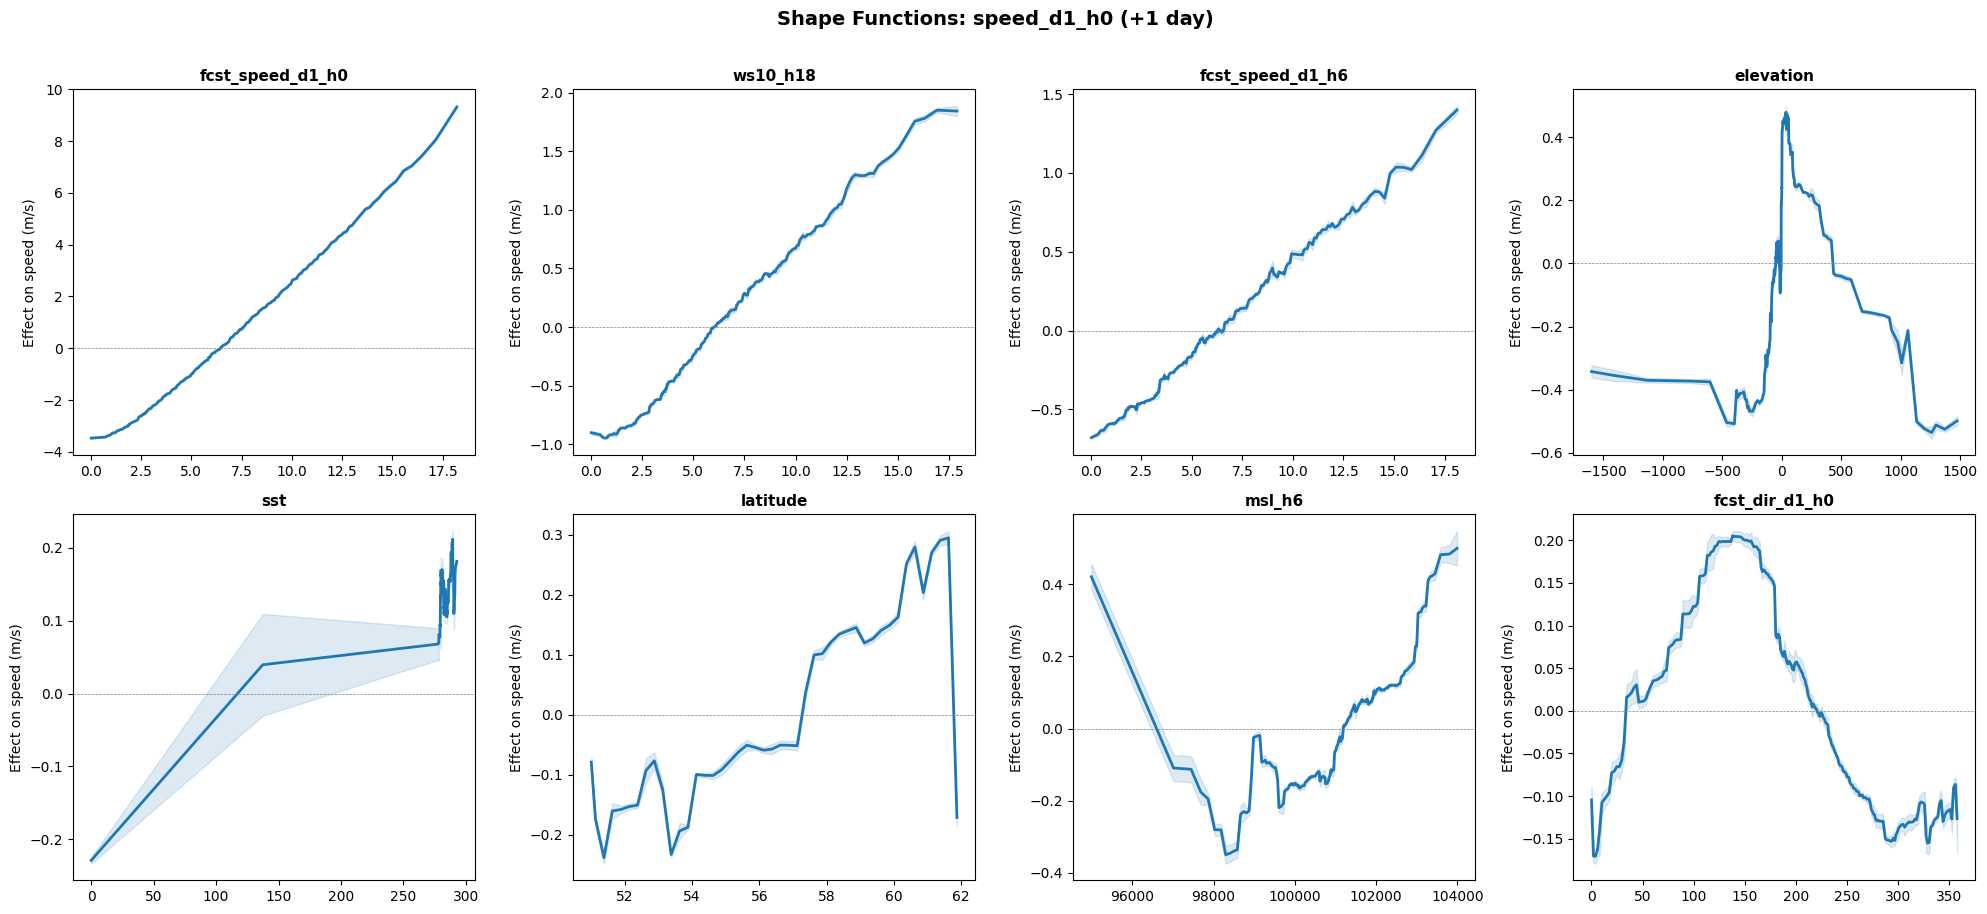

In [8]:
plot_shape_functions(ebm_models["speed_d1_h0"], "speed_d1_h0 (+1 day)")

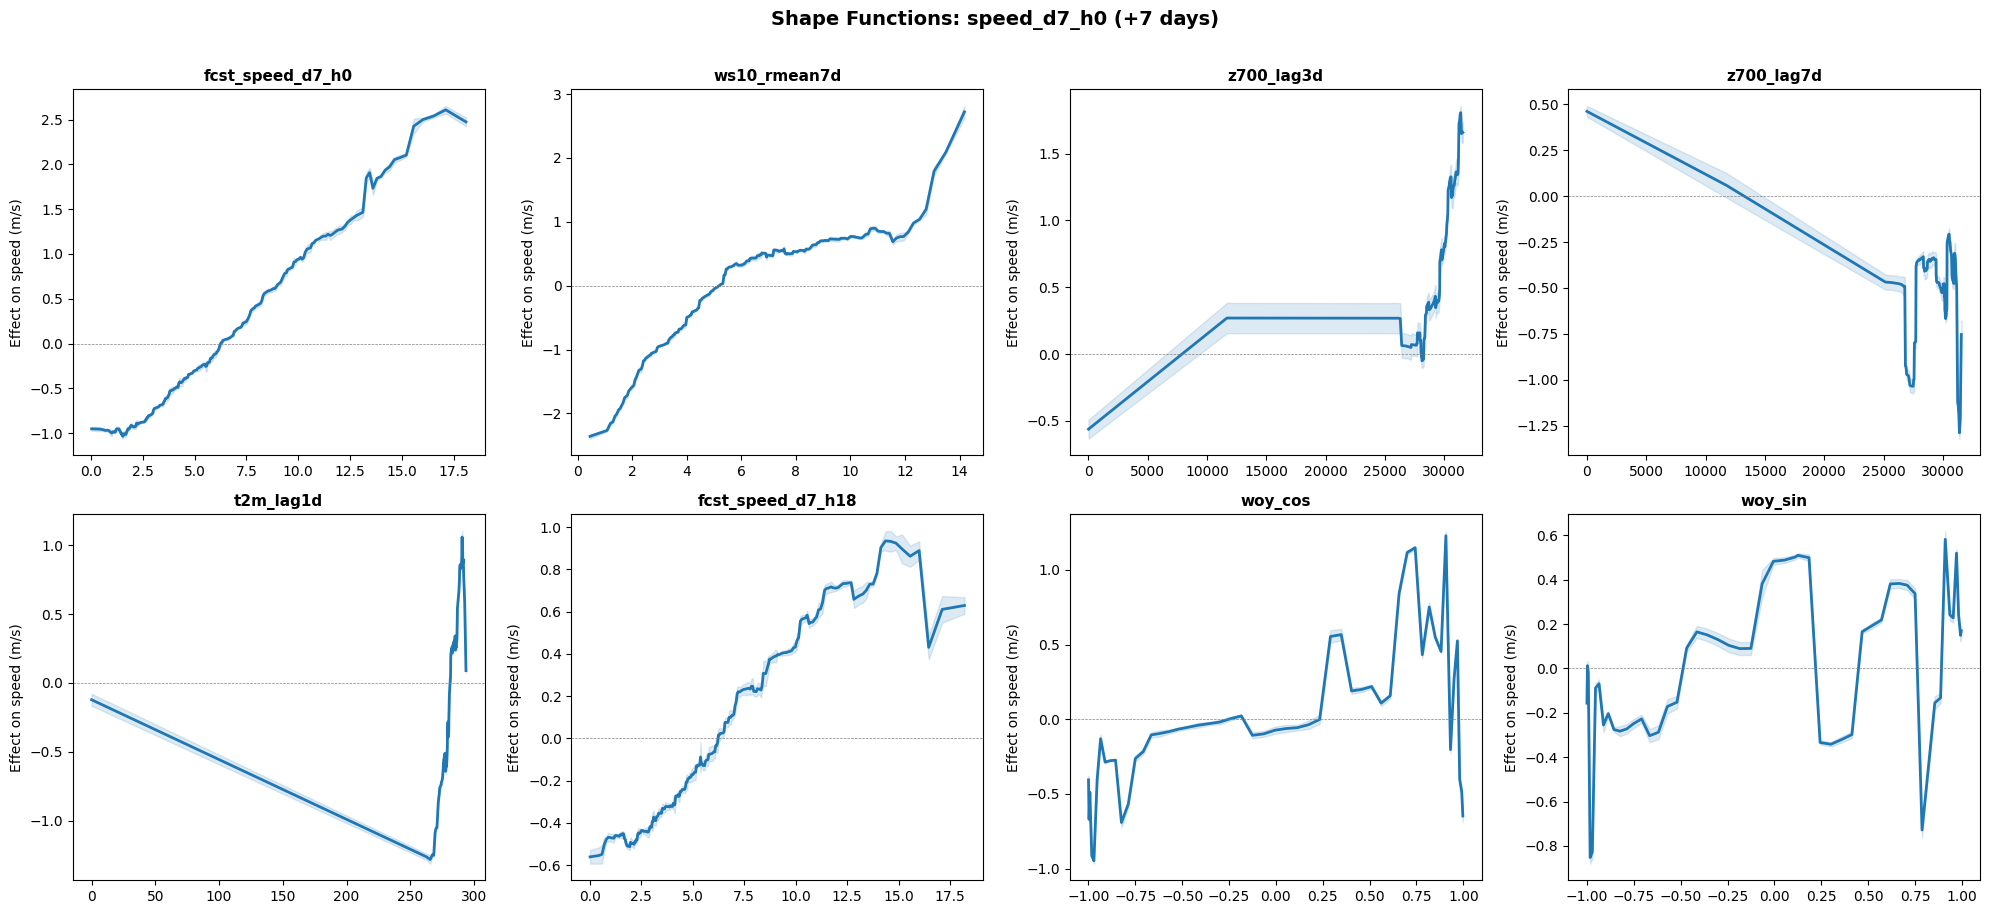

In [9]:
plot_shape_functions(ebm_models["speed_d7_h0"], "speed_d7_h0 (+7 days)")

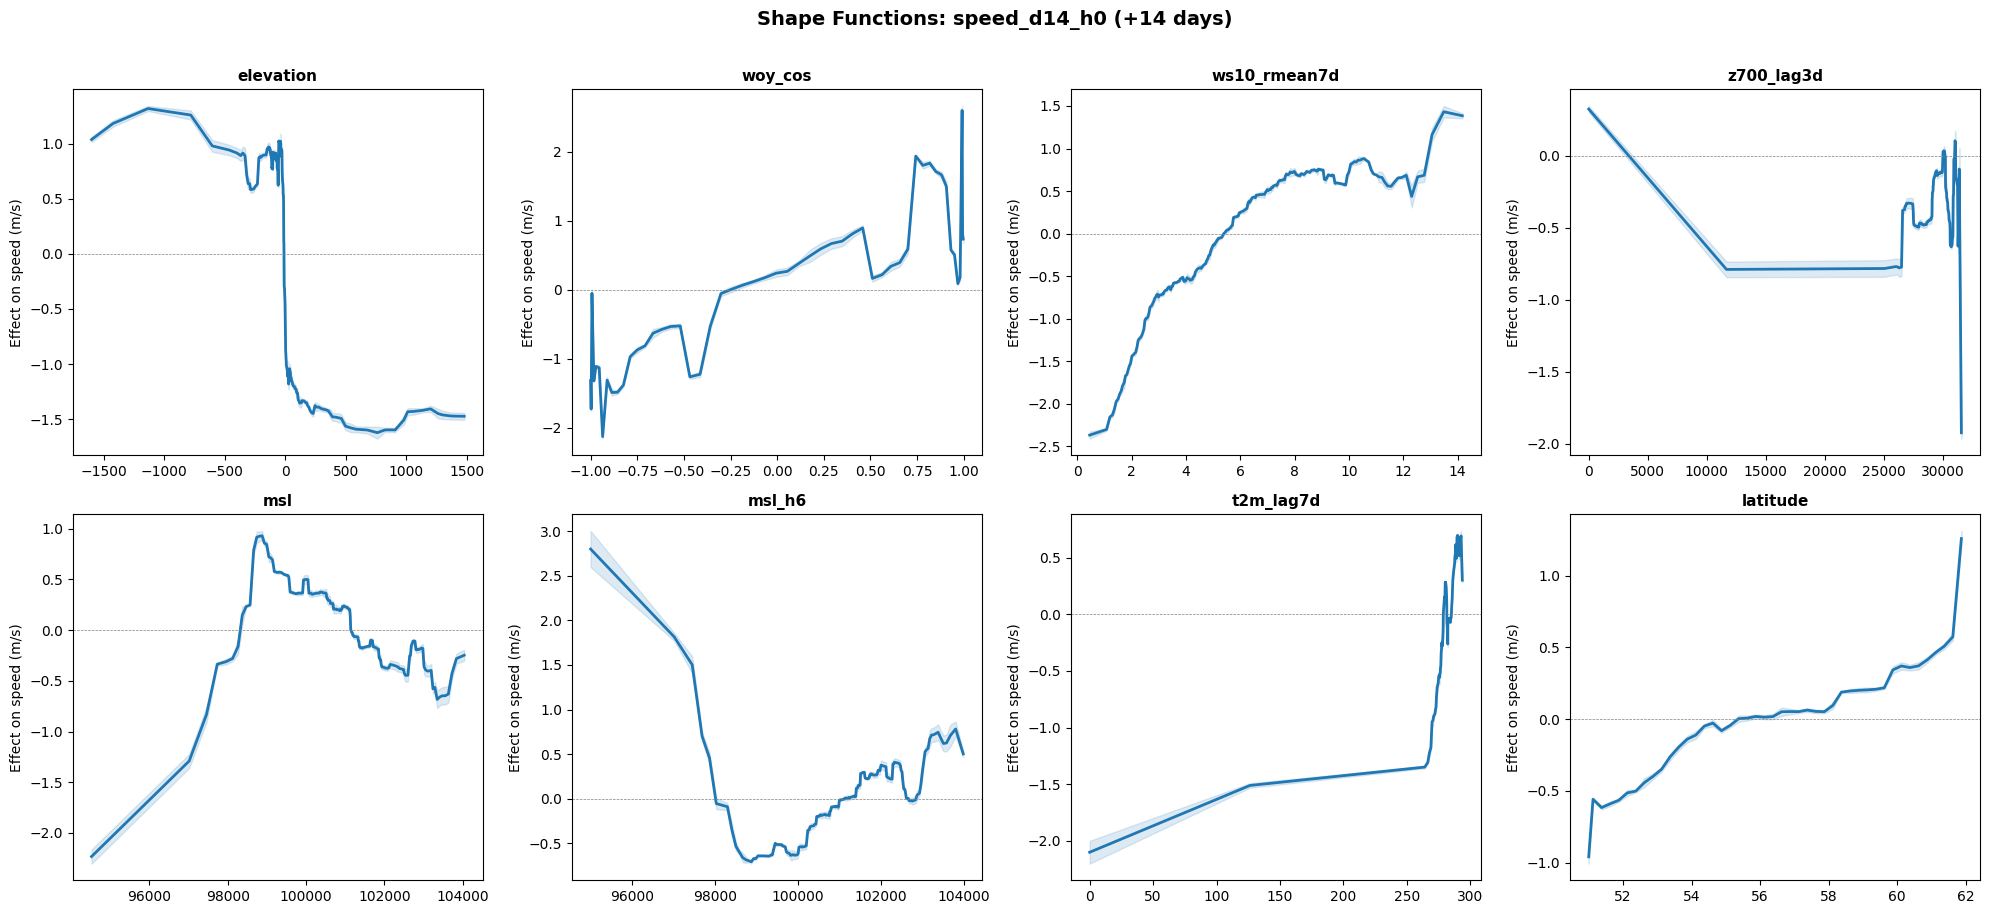

In [10]:
plot_shape_functions(ebm_models["speed_d14_h0"], "speed_d14_h0 (+14 days)")

## 8. Pairwise Interactions (EBM's unique strength)

EBMs automatically detect and learn the **strongest pairwise interactions**.

In [11]:
def plot_interactions(ebm, target_name, n_interactions=5):
    """Plot top-N pairwise interaction heatmaps from an EBM."""
    ebm_global = ebm.explain_global()

    all_names = ebm_global.data()["names"]
    all_scores = ebm_global.data()["scores"]

    # Find interaction terms (contain " & ")
    interactions = [
        (i, name, score)
        for i, (name, score) in enumerate(zip(all_names, all_scores))
        if " & " in name
    ]
    interactions.sort(key=lambda x: -x[2])

    n_plot = min(n_interactions, len(interactions))
    if n_plot == 0:
        print(f"No interactions detected for {target_name}.")
        return

    fig, axes = plt.subplots(1, n_plot, figsize=(5 * n_plot, 4.5))
    if n_plot == 1:
        axes = [axes]

    for j in range(n_plot):
        idx, name, importance = interactions[j]
        feat_data = ebm_global.data(idx)
        ax = axes[j]

        # Interaction data is a 2D grid
        x_names = feat_data["left_names"]
        y_names = feat_data["right_names"]
        scores_2d = np.array(feat_data["scores"])

        im = ax.imshow(
            scores_2d.T, aspect="auto", origin="lower",
            cmap="RdBu_r", interpolation="nearest",
        )
        plt.colorbar(im, ax=ax, shrink=0.8, label="Interaction effect (m/s)")

        # Tick labels (subsample if too many)
        n_xticks = min(6, len(x_names))
        n_yticks = min(6, len(y_names))
        xtick_idx = np.linspace(0, len(x_names) - 1, n_xticks, dtype=int)
        ytick_idx = np.linspace(0, len(y_names) - 1, n_yticks, dtype=int)
        ax.set_xticks(xtick_idx)
        ax.set_xticklabels([f"{x_names[k]:.2g}" if isinstance(x_names[k], (int, float))
                            else str(x_names[k]) for k in xtick_idx],
                           rotation=45, ha="right", fontsize=8)
        ax.set_yticks(ytick_idx)
        ax.set_yticklabels([f"{y_names[k]:.2g}" if isinstance(y_names[k], (int, float))
                            else str(y_names[k]) for k in ytick_idx], fontsize=8)

        pair = name.split(" & ")
        ax.set_xlabel(pair[0], fontsize=10)
        ax.set_ylabel(pair[1], fontsize=10)
        ax.set_title(f"{name}\n(imp={importance:.3f})", fontsize=10, fontweight="bold")

    fig.suptitle(f"Top-{n_plot} Pairwise Interactions: {target_name}",
                 fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()

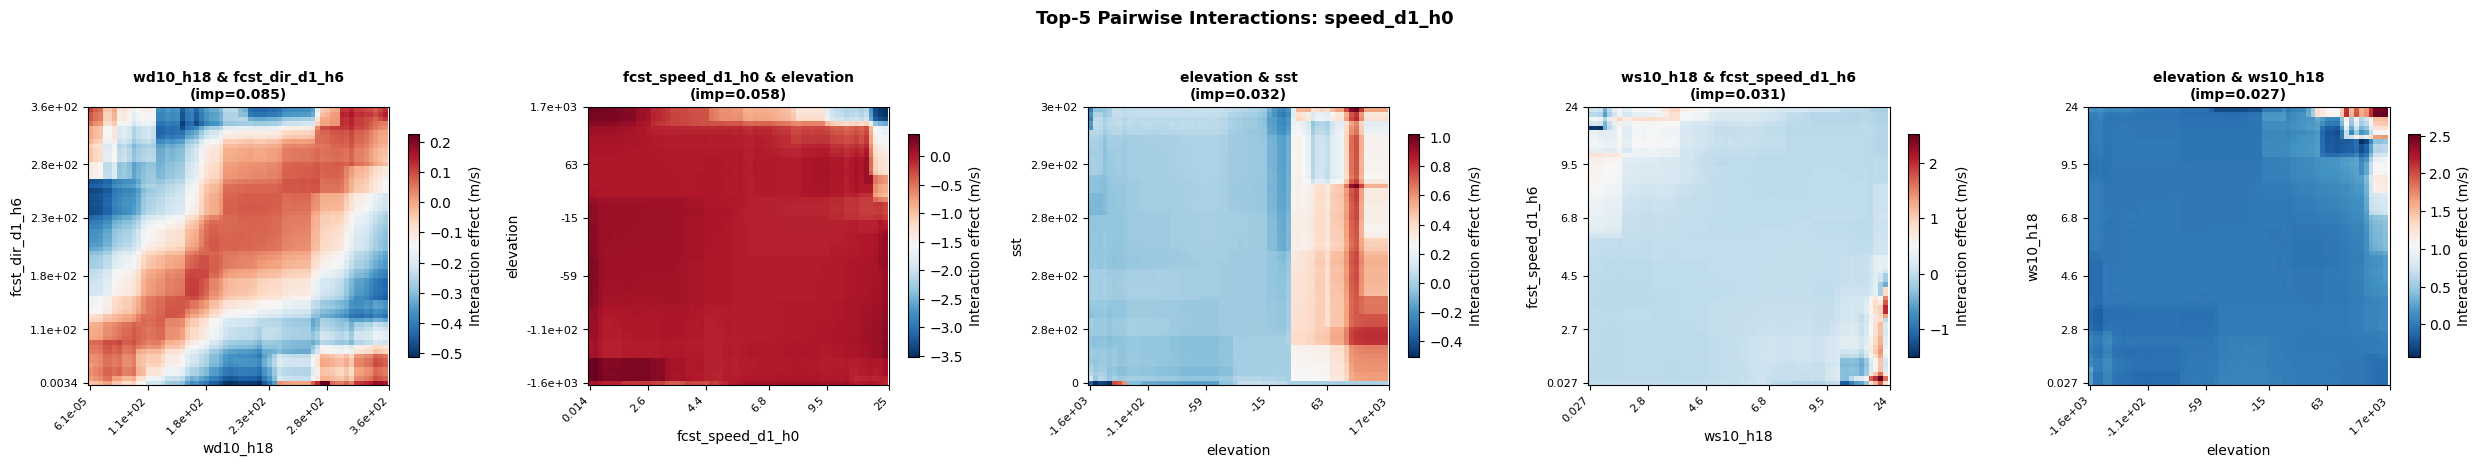

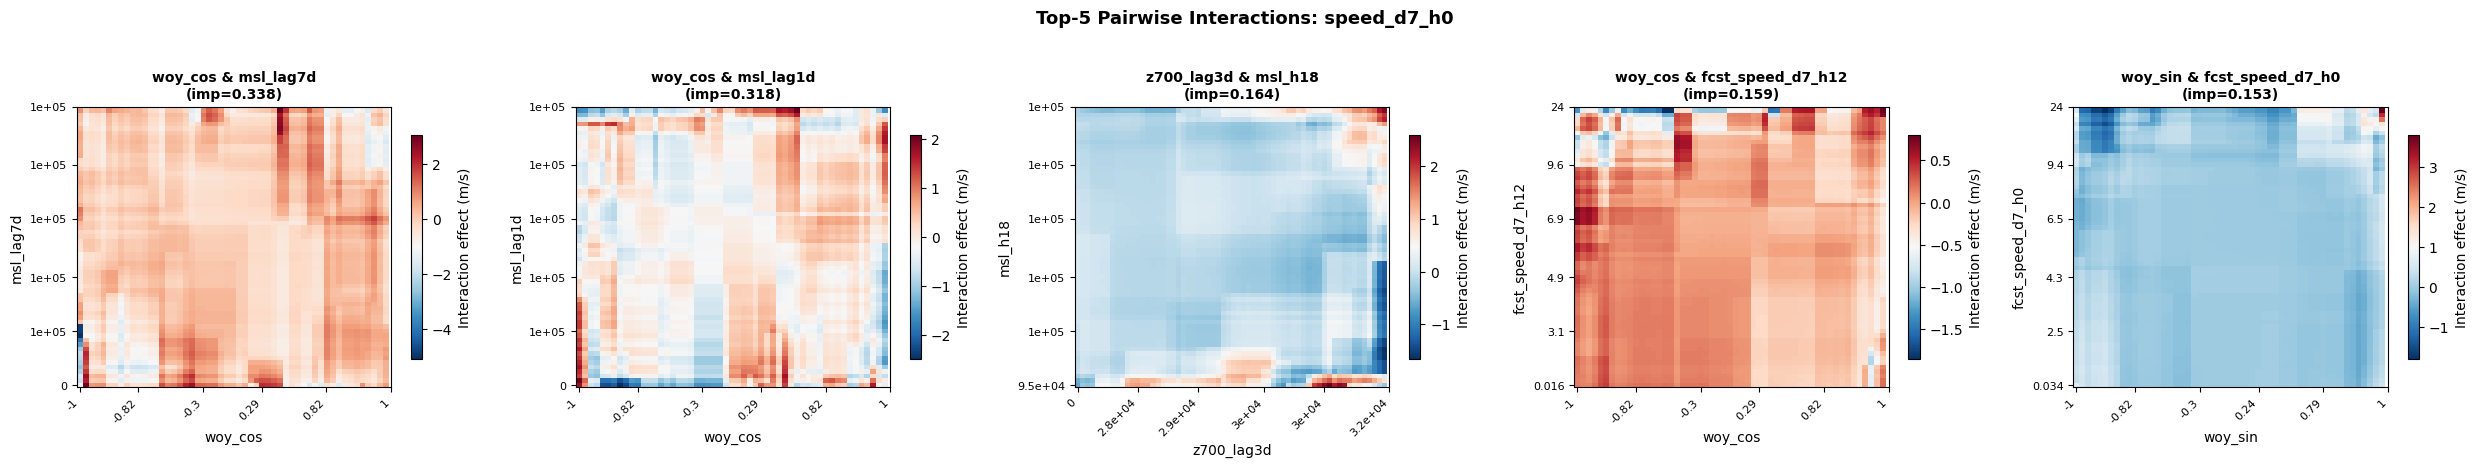

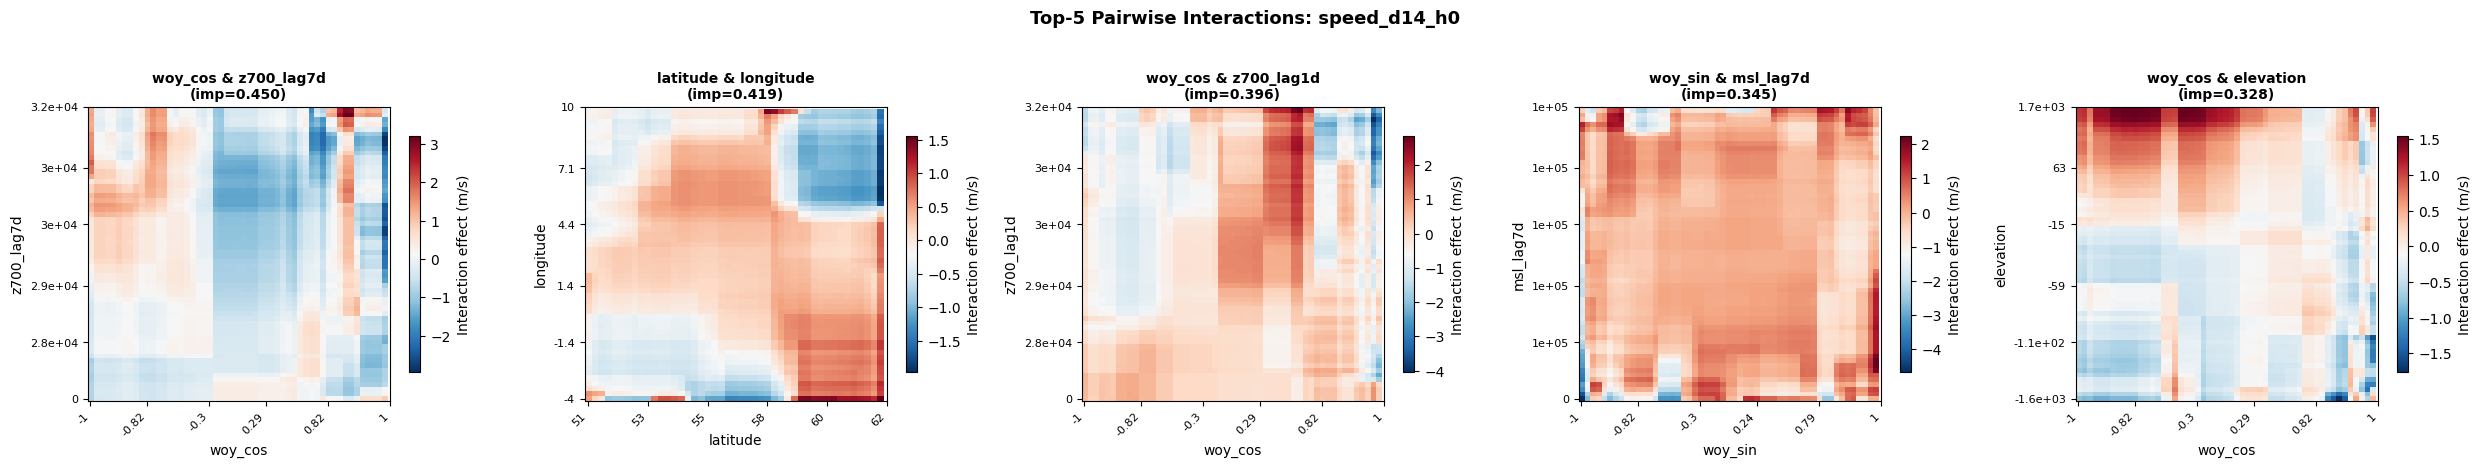

In [12]:
for tgt in EBM_TARGETS:
    plot_interactions(ebm_models[tgt], tgt, n_interactions=5)

## 10. EBM Predictions and Scoring

For completeness, we generate predictions on the validation set and compute RMSE.

In [15]:
results = []

for tgt in EBM_TARGETS:
    ebm = ebm_models[tgt]
    feats = selected_features[tgt]
    horizon = int(tgt.split("_")[1][1:])

    y_val = df_val_full[tgt].dropna()
    X_val = df_val_full.loc[y_val.index, feats].fillna(0)

    pred = ebm.predict(X_val)
    rmse = np.sqrt(np.mean((pred - y_val.values) ** 2))
    mae = np.mean(np.abs(pred - y_val.values))
    bias = np.mean(pred - y_val.values)

    results.append({
        "target": tgt,
        "horizon": f"+{horizon}d",
        "val_rmse": round(rmse, 3),
        "val_mae": round(mae, 3),
        "val_bias": round(bias, 3),
        "n_features": len(feats),
        "n_terms": len(ebm.term_names_),
        "n_interactions": sum(1 for t in ebm.term_names_ if " & " in t),
    })

results_df = pd.DataFrame(results)
print("EBM Validation Results (north_sea, h=0):\n")
print(results_df.to_string(index=False))

EBM Validation Results (north_sea, h=0):

      target horizon  val_rmse  val_mae  val_bias  n_features  n_terms  n_interactions
 speed_d1_h0     +1d     0.959    0.698    -0.015          25       35              10
 speed_d7_h0     +7d     3.065    2.329    -0.062          25       35              10
speed_d14_h0    +14d     3.409    2.650     0.240          25       35              10


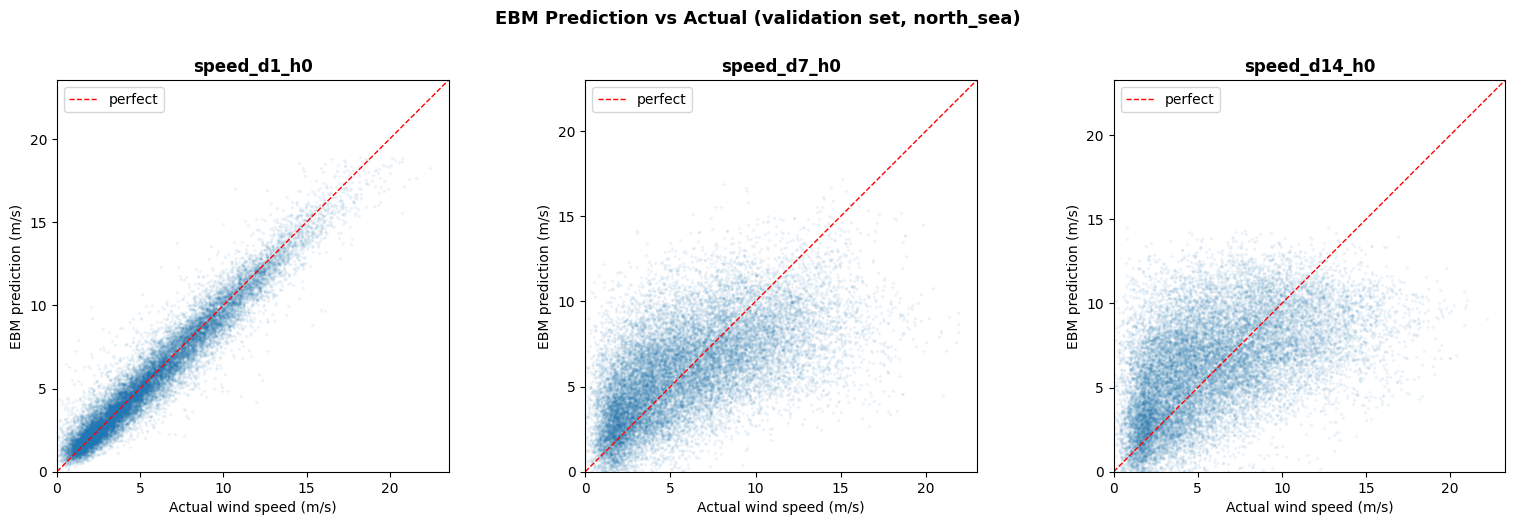

In [16]:
try:
    # Scatter: EBM prediction vs actual for each target
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for ax, tgt in zip(axes, EBM_TARGETS):
        ebm = ebm_models[tgt]
        feats = selected_features[tgt]
    
        y_val = df_val_full[tgt].dropna()
        X_val = df_val_full.loc[y_val.index, feats].fillna(0)
        pred = ebm.predict(X_val)
    
        # Subsample for plotting (too many points otherwise)
        n_plot = min(20_000, len(y_val))
        idx = np.random.RandomState(42).choice(len(y_val), n_plot, replace=False)
    
        ax.scatter(y_val.values[idx], pred[idx], alpha=0.05, s=2, color="#1f77b4")
        lims = [0, max(y_val.values[idx].max(), pred[idx].max()) * 1.05]
        ax.plot(lims, lims, "r--", linewidth=1, label="perfect")
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xlabel("Actual wind speed (m/s)")
        ax.set_ylabel("EBM prediction (m/s)")
        ax.set_title(tgt, fontweight="bold")
        ax.legend(loc="upper left")
        ax.set_aspect("equal")
    
    plt.suptitle("EBM Prediction vs Actual (validation set, north_sea)",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plot warning: {e} -- continuing")
